In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
may_2025 = pd.read_csv('data/202505-divvy-tripdata.csv')
june_2025 = pd.read_csv('data/202506-divvy-tripdata.csv')
july_2025 = pd.read_csv('data/202507-divvy-tripdata.csv')
august_2025 = pd.read_csv('data/202508-divvy-tripdata.csv')
september_2025 = pd.read_csv('data/202509-divvy-tripdata.csv')
october_2025 = pd.read_csv('data/202510-divvy-tripdata.csv')
november_2025 = pd.read_csv('data/202511-divvy-tripdata.csv')
december_2025 = pd.read_csv('data/202512-divvy-tripdata.csv')
january_2026 = pd.read_csv('data/202601-divvy-tripdata.csv')
february_2026 = pd.read_csv('data/202602-divvy-tripdata.csv')
march_2026 = pd.read_csv('data/202603-divvy-tripdata.csv')
april_2026 = pd.read_csv('data/202604-divvy-tripdata.csv')

In [3]:
# Check the consistency of the columns across all dataframes
dataframes = [may_2025, june_2025, july_2025, august_2025, september_2025, october_2025,
              november_2025, december_2025, january_2026, february_2026, march_2026, april_2026]

for i in range(len(dataframes) - 1):
    if not dataframes[i].columns.equals(dataframes[i + 1].columns):
        print(f"DataFrame {i} and DataFrame {i + 1} have different columns.")
    else:
        print(f"DataFrame {i} and DataFrame {i + 1} have the same columns.")       

DataFrame 0 and DataFrame 1 have the same columns.
DataFrame 1 and DataFrame 2 have the same columns.
DataFrame 2 and DataFrame 3 have the same columns.
DataFrame 3 and DataFrame 4 have the same columns.
DataFrame 4 and DataFrame 5 have the same columns.
DataFrame 5 and DataFrame 6 have the same columns.
DataFrame 6 and DataFrame 7 have the same columns.
DataFrame 7 and DataFrame 8 have the same columns.
DataFrame 8 and DataFrame 9 have the same columns.
DataFrame 9 and DataFrame 10 have the same columns.
DataFrame 10 and DataFrame 11 have the same columns.


In [4]:
df = pd.concat(dataframes, ignore_index=True)

In [5]:
df.shape

(5697455, 13)

In [6]:
df.duplicated().sum()

np.int64(0)

### Calculate new columns

In [7]:
# Ride Length
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['ride_length (minutes)'] = df['ended_at'] - df['started_at']

# Convert ride_length to minutes, rounded to 2 decimal places
df['ride_length (minutes)'] = df['ride_length (minutes)'].dt.total_seconds() / 60
df['ride_length (minutes)'] = df['ride_length (minutes)'].round(2)
df.head(5)

# Day of week
df['day_of_week'] = df['started_at'].dt.weekday + 1

# new Month column (for monthly/seasonal analysis)
df['month'] = df['started_at'].dt.month

# new Hour column (for hourly analysis)
df['hour'] = df['started_at'].dt.hour
hour_map = {
    0: '12 a.m.', 1: '1 a.m.', 2: '2 a.m.', 3: '3 a.m.', 4: '4 a.m.', 5: '5 a.m.',
    6: '6 a.m.', 7: '7 a.m.', 8: '8 a.m.', 9: '9 a.m.', 10: '10 a.m.', 11: '11 a.m.',
    12: '12 p.m.', 13: '1 p.m.', 14: '2 p.m.', 15: '3 p.m.', 16: '4 p.m.', 17: '5 p.m.',
    18: '6 p.m.', 19: '7 p.m.', 20: '8 p.m.', 21: '9 p.m.', 22: '10 p.m.', 23: '11 p.m.'
}
df['hour'] = df['hour'].map(hour_map)



In [8]:
df.shape

(5697455, 17)

### Cleaning
- removed all rows that have ride lengths that are negative, under 1 minute, or over 24 hours

In [9]:
df.isna().sum()

ride_id                        0
rideable_type                  0
started_at                     0
ended_at                       0
start_station_name       1215745
start_station_id         1215745
end_station_name         1279863
end_station_id           1279863
start_lat                      0
start_lng                      0
end_lat                     5857
end_lng                     5857
member_casual                  0
ride_length (minutes)          0
day_of_week                    0
month                          0
hour                           0
dtype: int64

In [10]:
# remove missing values
#df = df.dropna()
#df.shape


In [11]:
# remove ride times that are negative or zero
df = df[df['ride_length (minutes)'] > 0]
df.shape


(5697299, 17)

In [12]:
# remove ride times that are under 1 minute
df = df[df['ride_length (minutes)'] >= 1]
df.shape

(5541823, 17)

In [13]:
# remove ride times that are over 24 hours (1440 minutes)
df = df[df['ride_length (minutes)'] <= 1440]
df.shape

(5535990, 17)

In [14]:
df.to_csv('divvy_cleaned.csv', index=False)

### Descriptive analytics

In [15]:
# mean and max ride length
mean_ride_length = df['ride_length (minutes)'].mean()
max_ride_length = df['ride_length (minutes)'].max()
print(f"Mean ride length: {mean_ride_length} minutes")
print(f"Max ride length: {max_ride_length} minutes")

# mode of Day of Week
mode_day_of_week = df['started_at'].dt.day_name().mode()[0]
print(f"Most common day of the week for rides: {mode_day_of_week}")


Mean ride length: 14.89366953697532 minutes
Max ride length: 1439.98 minutes
Most common day of the week for rides: Thursday


In [ ]:
# Count the number of rides that exceed x minutes

# n = 1440
# long_rides_count = df[df['ride_length (minutes)'] > n].shape[0]
# print(f"Number of rides that exceed {n} minutes: {long_rides_count}")

Number of rides that exceed 1440 minutes: 0


In [ ]:
sns.set_theme(font_scale=0.7)

In [ ]:
# Count of bike types among casual/annual members
bike_type_counts = df.groupby(['member_casual', 'rideable_type']).size().unstack(fill_value=0)
print(bike_type_counts)

# Plot the distribution of bike types among casual/annual members
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rideable_type', hue='member_casual')
plt.title('Distribution of Bike Types Among Casual vs Annual Members')
plt.ticklabel_format(style='plain', axis='y')  
plt.xlabel('Bike Type')
plt.ylabel('Number of Rides')
plt.legend(title='Member Type')
plt.show()

In [ ]:
# Average ride times on each day of the week (monday = 1, ..., sunday = 7)
avg_ride_length_by_day = df.groupby('day_of_week')['ride_length (minutes)'].mean()

# Plot average ride times on each day of the week
plt.figure(figsize=(6, 4))
sns.barplot(x=avg_ride_length_by_day.index, y=avg_ride_length_by_day.values)
plt.xlabel('Day of the Week')
plt.ylabel('Average Ride Length (minutes)')
plt.title('Average Ride Length by Day of the Week')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

In [ ]:
# Average ride times of casual vs annual riders
avg_ride_length_by_member_type = df.groupby('member_casual')['ride_length (minutes)'].mean()
print(avg_ride_length_by_member_type)

In [ ]:
# Ratio of casual vs annual riders on each day of the week
member_type_counts_by_day = df.groupby(['day_of_week', 'member_casual']).size().unstack(fill_value=0)
member_type_ratio_by_day = member_type_counts_by_day.div(member_type_counts_by_day.sum(axis=1), axis=0)
print(member_type_ratio_by_day)

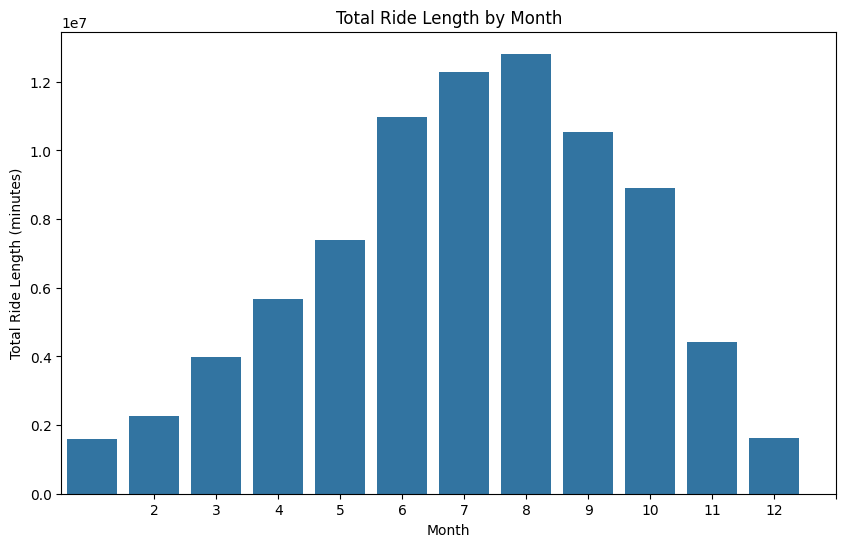

In [24]:
# Total ride length by month
total_ride_length_by_month = df.groupby('month')['ride_length (minutes)'].sum()

# Plot total ride length by month
plt.figure(figsize=(10, 6))
sns.barplot(x=total_ride_length_by_month.index, y=total_ride_length_by_month.values)
plt.title('Total Ride Length by Month')
plt.xlabel('Month')
plt.ylabel('Total Ride Length (minutes)')
plt.xticks(total_ride_length_by_month.index)
plt.show()

In [ ]:
# Total number of rides by month
total_rides_by_month = df.groupby('month').size()

# Plot total number of rides by month
plt.figure(figsize=(10, 6))
sns.barplot(x=total_rides_by_month.index, y=total_rides_by_month.values)
plt.title('Total Number of Rides by Month')
plt.xlabel('Month')
plt.ylabel('Total Number of Rides')
plt.xticks(total_rides_by_month.index)
plt.show()